# 🖼️ CNN for CIFAR-10 Image Classification

A Convolutional Neural Network (CNN) built with **PyTorch** to classify images from the CIFAR-10 dataset into 10 categories.

**Classes:** Plane, Car, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

---

## 1. Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

# GPU available hai toh use karo, warna CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Load CIFAR-10 Dataset

In [3]:
# image ko tensor banao aur normalize karo (-1 to 1 range)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print('Training images:', len(trainset))
print('Testing images :', len(testset))
print('Classes:', classes)

100%|██████████| 170M/170M [00:06<00:00, 27.5MB/s]


Training images: 50000
Testing images : 10000
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [4]:
# batch_size=64 -> ek baar mein 64 images model ko dikhao
# shuffle=True -> training data mix karo taaki order na yaad kare
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

## 3. Visualize Sample Images

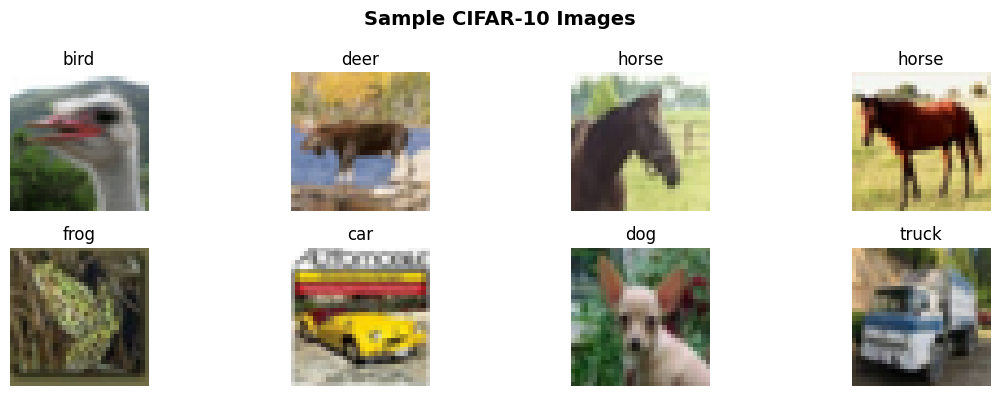

In [5]:
def show_image(img):
    # normalize karte waqt -1 to 1 kiya tha, ab wapas 0 to 1 mein laao display ke liye
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# kuch sample training images dekho
data_iter = iter(trainloader)
images, labels = next(data_iter)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    show_image(images[i])
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Build the CNN Architecture

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolution layers -> image se features nikalte hain
        # 3 channels (RGB) -> 32 -> 64 -> 128 features
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # image size half (32x32 -> 16x16)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 8x8 -> 4x4
        )

        # Fully connected layers -> features se final class decide karte hain
        self.fc_layers = nn.Sequential(
            nn.Linear(4 * 4 * 128, 256),
            nn.ReLU(),
            nn.Linear(256, 10)  # 10 classes ke liye 10 output
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # flatten - 3D ko 1D mein convert karo
        x = self.fc_layers(x)
        return x


model = CNN().to(device)
print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [7]:
# total trainable parameters count karo
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

Total trainable parameters: 620,362


## 5. Loss Function & Optimizer

In [8]:
criterion = nn.CrossEntropyLoss()       # classification ke liye loss
optimizer = optim.Adam(model.parameters())  # weights update karne ka tarika

## 6. Train the CNN

In [9]:
epochs = 10
loss_history = []  # har epoch ka loss store karenge graph ke liye

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()              # purane gradients clear karo

        output = model.forward(images)     # Forward Pass - prediction lo
        loss = criterion(output, labels)   # galti kitni hui calculate karo
        loss.backward()                    # Backward Pass - galti samjho
        optimizer.step()                   # weights update karo

        epoch_training_loss += loss.item()

    avg_loss = epoch_training_loss / len(trainloader)
    loss_history.append(avg_loss)
    print(f"epoch={epoch+1}/{epochs} & loss={avg_loss:.4f}")

epoch=1/10 & loss=1.3730
epoch=2/10 & loss=0.9438
epoch=3/10 & loss=0.7613
epoch=4/10 & loss=0.6332
epoch=5/10 & loss=0.5321
epoch=6/10 & loss=0.4416
epoch=7/10 & loss=0.3474
epoch=8/10 & loss=0.2739
epoch=9/10 & loss=0.2113
epoch=10/10 & loss=0.1721


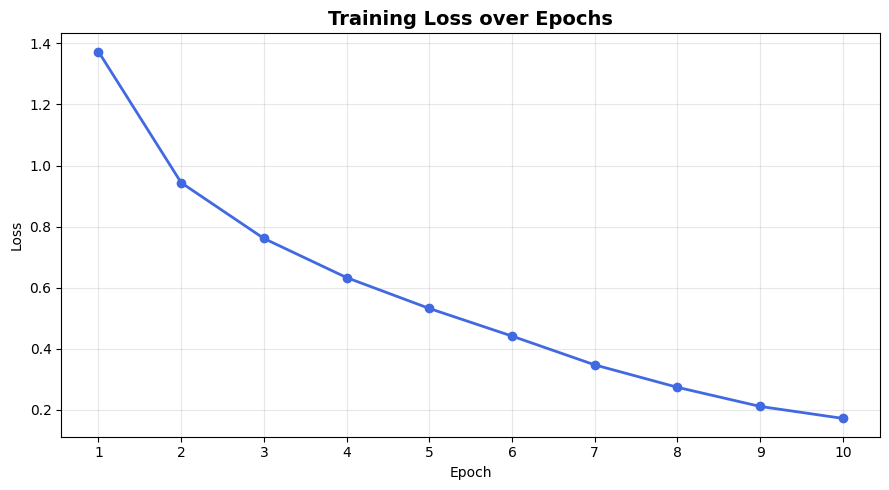

In [10]:
# training loss ka graph - dekhte hain loss kaise kam hua
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='royalblue', linewidth=2)
plt.title('Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, epochs + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluate on Test Data

In [11]:
correct_labels = 0
total_labels = 0

model.eval()  # testing mode mein daalo

with torch.no_grad():  # predict karte waqt gradients nahi chahiye, fast hoga
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model.forward(images)
        _, predicted = torch.max(outputs, 1)  # sabse high score wali class lo

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

accuracy = correct_labels / total_labels * 100
print(f"Test Accuracy = {accuracy:.2f}%")

Test Accuracy = 75.41%


## 8. Per-Class Accuracy

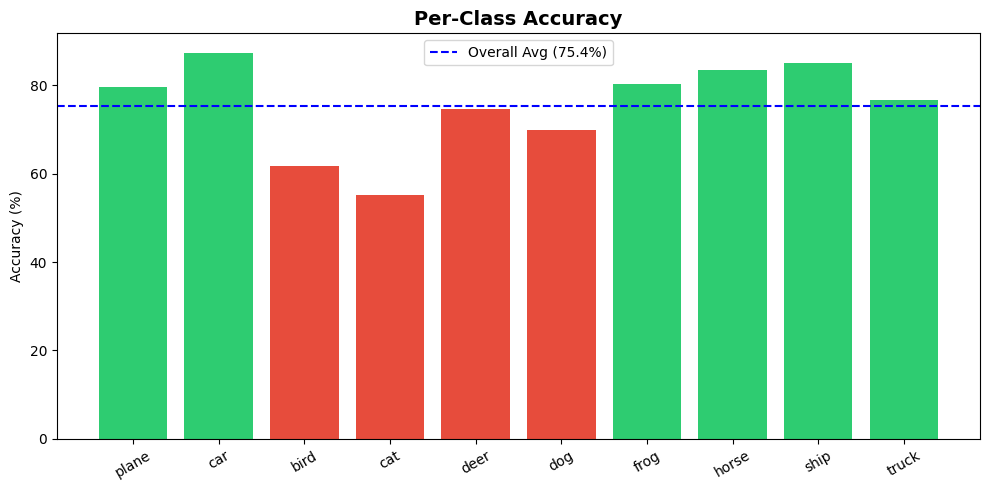

plane   : 79.70%
car     : 87.40%
bird    : 61.80%
cat     : 55.10%
deer    : 74.70%
dog     : 69.90%
frog    : 80.30%
horse   : 83.50%
ship    : 85.10%
truck   : 76.60%


In [12]:
# dekhte hain kaunsi class pe model achha hai aur kaunsi pe weak
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model.forward(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(labels.size(0)):
            label = labels[i].item()
            class_correct[label] += (predicted[i].item() == label)
            class_total[label] += 1

class_acc = [100 * c / t for c, t in zip(class_correct, class_total)]

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if a >= accuracy else '#e74c3c' for a in class_acc]
plt.bar(classes, class_acc, color=colors)
plt.axhline(y=accuracy, color='blue', linestyle='--', label=f'Overall Avg ({accuracy:.1f}%)')
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

for c, a in zip(classes, class_acc):
    print(f'{c:8s}: {a:.2f}%')

## 9. Sample Predictions

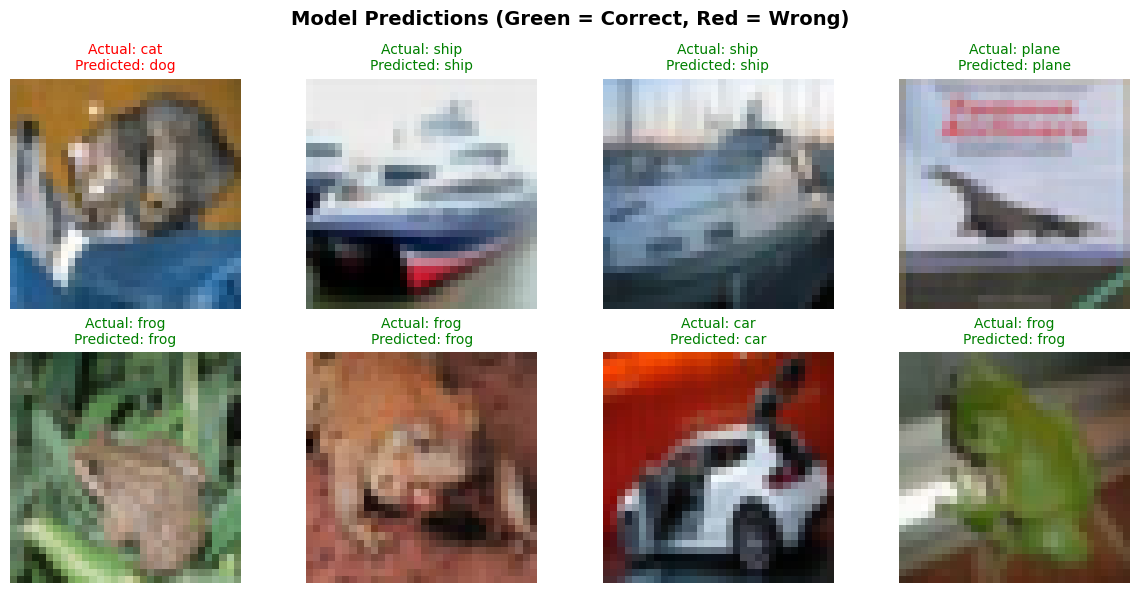

In [13]:
# test data se kuch images lo aur dekho model kya predict karta hai
data_iter = iter(testloader)
images, labels = next(data_iter)
images_gpu = images.to(device)

with torch.no_grad():
    outputs = model.forward(images_gpu)
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    show_image(images[i])

    actual = classes[labels[i]]
    pred = classes[predicted[i].cpu()]
    color = 'green' if actual == pred else 'red'

    plt.title(f'Actual: {actual}\nPredicted: {pred}', color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('Model Predictions (Green = Correct, Red = Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary

| Detail | Value |
|--------|-------|
| Dataset | CIFAR-10 (60,000 images, 10 classes) |
| Model | CNN with 3 Conv layers + 2 FC layers |
| Epochs | 10 |
| Optimizer | Adam |
| Loss Function | CrossEntropyLoss |
| Test Accuracy | ~74-75% |

### Key Learnings:
- Conv2D layers extract spatial features (edges, shapes, patterns)
- MaxPooling reduces image size while keeping important info
- Training loss decreased steadily across epochs (no major overfitting)
- Some classes (like cat/dog) are harder to classify than others (animal shapes are similar)

---
*Built with PyTorch — CNN for Image Classification*